# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

El porcentaje de grasa corporal es un indicador de salud más útil que el peso o el índice de masa corporal, pero su medición de referencia, el pesaje hidrostático, necesita equipo especializado. Queremos estimarlo con medidas que cualquier persona puede tomar con una balanza y una cinta métrica: edad, peso, estatura y diez circunferencias.

El asistente JarvisTEC usa este modelo para responder a la pregunta "qué porcentaje de grasa corporal tengo" a partir de los datos que el usuario escribe en un formulario. Es un problema de **regresión supervisada** y la variable objetivo es `BodyFat`, en porcentaje.

# Caso Aplicado: Porcentaje de Grasa Corporal
## Regresión regularizada con medidas corporales

---

**Temas:** Fuga de información · Multicolinealidad · Regresión lineal, Ridge y Lasso · Validación cruzada  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento y limpieza | ¿Qué forma tienen los datos y hay registros imposibles? |
| 2 — Exploración | ¿Qué medidas se relacionan con la grasa, y hay una variable que no se puede usar? |
| 3 — Modelo | ¿Qué regresión predice mejor y cómo se compara con predecir siempre el promedio? |
| 4 — Predicción | ¿Qué porcentaje de grasa se estima para una persona nueva? |

> Nota: el objetivo no es solo ajustar un buen modelo. También hay que reconocer qué datos no se pueden usar en la práctica y qué tan confiable es el resultado.

Este notebook es un extra del modelo 08 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

El conjunto reúne 252 hombres adultos con medidas corporales. El porcentaje de grasa se estimó con pesaje hidrostático (Penrose et al., 1985; Johnson, 1996). Todas las variables son cuantitativas:

- BodyFat   : variable objetivo, porcentaje de grasa corporal
- Density   : densidad corporal (g/cm3), **no se usa**, se explica más adelante
- Age       : edad en años
- Weight    : peso en libras
- Height    : estatura en pulgadas
- Neck, Chest, Abdomen, Hip, Thigh, Knee, Ankle, Biceps, Forearm, Wrist : circunferencias en centímetros

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_08_grasa_corporal/` del repositorio. Son 252 filas y 15 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA)
datos.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [4]:
# Describir el dataset
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
Density,252.0,1.055574,0.019031,0.995,1.0414,1.0549,1.0704,1.1089
BodyFat,252.0,19.150794,8.368740,0.000,12.4750,19.2000,25.3000,47.5000
Age,252.0,44.884921,12.602040,22.000,35.7500,43.0000,54.0000,81.0000
Weight,252.0,178.924405,29.389160,118.500,159.0000,176.5000,197.0000,363.1500
Height,252.0,70.148810,3.662856,29.500,68.2500,70.0000,72.2500,77.7500
Neck,252.0,37.992063,2.430913,31.100,36.4000,38.0000,39.4250,51.2000
Chest,252.0,100.824206,8.430476,79.300,94.3500,99.6500,105.3750,136.2000
Abdomen,252.0,92.555952,10.783077,69.400,84.5750,90.9500,99.3250,148.1000
Hip,252.0,99.904762,7.164058,85.000,95.5000,99.3000,103.5250,147.7000
Thigh,252.0,59.405952,5.249952,47.200,56.0000,59.0000,62.3500,87.3000


In [5]:
# Información del dataset
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [6]:
print("Cantidad de registros:", len(datos))
print("Cantidad de columnas:", len(datos.columns))
print("Tipo de datos:", datos.dtypes.unique())
print("Filas y columnas:", datos.shape)
print("Valores nulos:", int(datos.isnull().sum().sum()))

Cantidad de registros: 252
Cantidad de columnas: 15
Tipo de datos: [dtype('float64') dtype('int64')]
Filas y columnas: (252, 15)
Valores nulos: 0


El formulario de la aplicación usa las unidades que la gente conoce, así que se pasa el peso a kilogramos y la estatura a centímetros, y se renombran las columnas.

In [7]:
LB_A_KG = 0.45359237
PULGADA_A_CM = 2.54

df = datos.copy()
df.columns = [c.lower() for c in df.columns]
df["weight_kg"] = (df.pop("weight") * LB_A_KG).round(2)
df["height_cm"] = (df.pop("height") * PULGADA_A_CM).round(1)
df = df.rename(columns={c: f"{c}_cm" for c in
                        ["neck", "chest", "abdomen", "hip", "thigh", "knee", "ankle", "biceps", "forearm", "wrist"]})
df.head()

,density,bodyfat,age,neck_cm,chest_cm,abdomen_cm,hip_cm,thigh_cm,knee_cm,ankle_cm,biceps_cm,forearm_cm,wrist_cm,weight_kg,height_cm
0,1.0708,12.3,23,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,69.97,172.1
1,1.0853,6.1,22,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,78.58,183.5
2,1.0414,25.3,22,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,69.85,168.3
3,1.0751,10.4,26,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2,83.80,183.5
4,1.0340,28.7,24,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7,83.57,181.0


### Registros imposibles

Es importante revisar los extremos antes de entrenar. Se descartan solo los registros físicamente imposibles: una persona con 0 % de grasa y otra con 75 cm de estatura (un error de digitación evidente). Los dos casos coinciden con errores que ya señala la literatura del dataset (Johnson, 1996). Los demás extremos son posibles y se conservan.

In [8]:
imposibles = (df["bodyfat"] <= 0) | (df["height_cm"] < 120)
print("Registros imposibles descartados:", int(imposibles.sum()), "-> filas", df.index[imposibles].tolist())
df = df[~imposibles].reset_index(drop=True)
print("Quedan", len(df), "registros")

Registros imposibles descartados: 2 -> filas [41, 181]
Quedan 250 registros


---
# Sección 2: Exploración y Selección de Predictores
---

## Exploración de los Datos

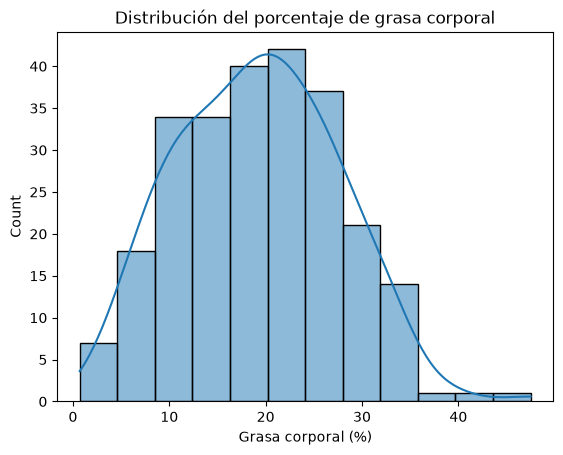

Media: 19.2 %  Desviación: 8.3


In [9]:
sns.histplot(df["bodyfat"], kde=True)
plt.xlabel("Grasa corporal (%)")
plt.title("Distribución del porcentaje de grasa corporal")
plt.show()
print("Media: %.1f %%  Desviación: %.1f" % (df["bodyfat"].mean(), df["bodyfat"].std()))

La distribución es aproximadamente simétrica, con una media cercana al 19 %.

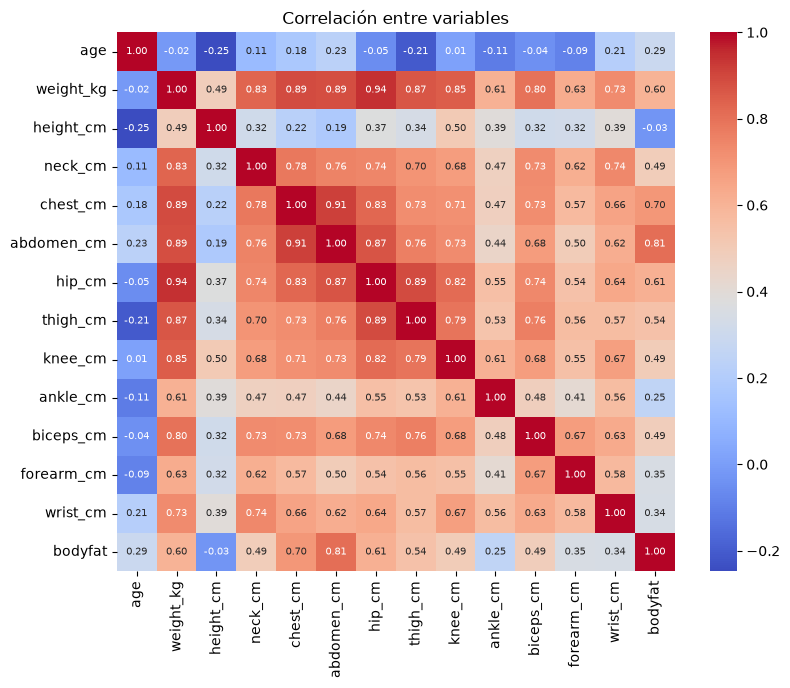

height_cm    -0.03
ankle_cm      0.25
age           0.29
wrist_cm      0.34
forearm_cm    0.35
biceps_cm     0.49
neck_cm       0.49
knee_cm       0.49
thigh_cm      0.54
weight_kg     0.60
hip_cm        0.61
chest_cm      0.70
abdomen_cm    0.81
Name: bodyfat, dtype: float64

In [10]:
VARIABLES = ["age", "weight_kg", "height_cm", "neck_cm", "chest_cm", "abdomen_cm", "hip_cm", "thigh_cm", "knee_cm", "ankle_cm", "biceps_cm", "forearm_cm", "wrist_cm"]
OBJETIVO = "bodyfat"

corr = df[VARIABLES + [OBJETIVO]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size": 7})
plt.title("Correlación entre variables")
plt.show()
corr[OBJETIVO].drop(OBJETIVO).sort_values().round(2)

> Analogía: cuando dos variables predictoras están muy correlacionadas entre sí, es como pedirle a dos testigos que vieron exactamente lo mismo que declaren por separado. El modelo no puede distinguir el aporte real de cada uno y sus coeficientes se vuelven inestables.

**Multicolinealidad**

La circunferencia del abdomen es la variable más asociada a la grasa (r = 0.81), seguida del pecho, la cadera y el peso. La estatura casi no se relaciona. Además, las circunferencias están muy correlacionadas entre sí (peso y cadera, r = 0.94). Esto es un argumento para probar modelos con regularización (Ridge y Lasso).

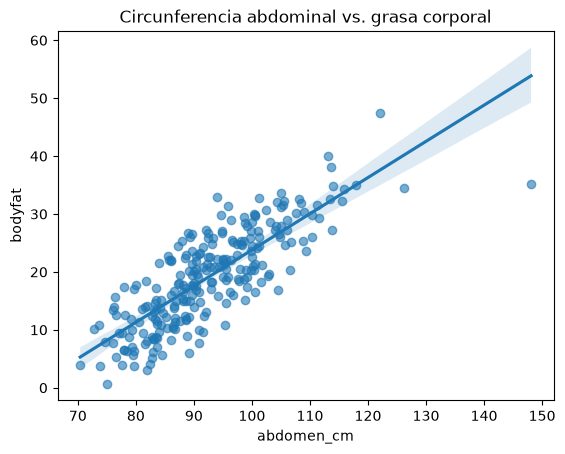

In [11]:
sns.regplot(data=df, x="abdomen_cm", y=OBJETIVO, scatter_kws={"alpha": 0.6})
plt.title("Circunferencia abdominal vs. grasa corporal")
plt.show()

La relación entre el abdomen y la grasa es aproximadamente lineal, lo que justifica empezar con modelos lineales.

### Una variable que no se puede usar: Density

`BodyFat` no es una medición independiente: se calcula a partir de la densidad corporal con la ecuación de Siri (1956). La correlación entre las dos es de -0.99. Veamos qué pasa si se incluye.

In [12]:
print("Correlación Density vs BodyFat: %.3f" % df["density"].corr(df["bodyfat"]))

X_tr, X_te, y_tr, y_te = train_test_split(df[VARIABLES + ["density"]], df[OBJETIVO], test_size=0.2, random_state=SEMILLA)
con_densidad = Pipeline([("escala", StandardScaler()), ("modelo", LinearRegression())]).fit(X_tr, y_tr)
print("R2 de prueba con Density: %.3f" % r2_score(y_te, con_densidad.predict(X_te)))

Correlación Density vs BodyFat: -0.988
R2 de prueba con Density: 0.994


El R2 de 0.99 es engañoso: la variable ya contiene la respuesta. Medir la densidad exige el mismo pesaje hidrostático que se quiere evitar, así que **se descarta**. A esto se le llama fuga de información.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

Primero se divide el conjunto en 80 % para entrenamiento y 20 % para prueba.

In [13]:
X, y = df[VARIABLES], df[OBJETIVO]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEMILLA)
print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)

Entrenamiento: (200, 13)  Prueba: (50, 13)


> Es importante siempre validar los rangos de los conjuntos creados, para evitar caer en extrapolación:

In [14]:
pd.DataFrame({"entrenamiento_min": X_train.min(), "entrenamiento_max": X_train.max(),
              "prueba_min": X_test.min(), "prueba_max": X_test.max()}).round(1)

,entrenamiento_min,entrenamiento_max,prueba_min,prueba_max
age,22.0,81.0,23.0,72.0
weight_kg,56.7,119.2,60.6,164.7
height_cm,162.6,197.5,167.6,189.2
neck_cm,31.5,43.9,31.1,51.2
chest_cm,83.4,128.3,88.2,136.2
abdomen_cm,70.4,126.2,73.7,148.1
hip_cm,85.3,125.6,88.5,147.7
thigh_cm,49.3,74.4,51.2,87.3
knee_cm,33.0,46.0,34.5,49.1
ankle_cm,19.1,33.7,21.0,33.9


Hay una persona en la prueba con 165 kg y 148 cm de abdomen, mucho más que cualquiera del entrenamiento (119 kg y 126 cm como máximo). Los modelos lineales extrapolan mal fuera de lo que vieron, y eso se nota en la evaluación.

### Candidatos

Cada candidato es un `Pipeline` que incluye su preprocesamiento. La selección se hace **solo con el entrenamiento**, con validación cruzada repetida (5 particiones por 3 repeticiones). La prueba se usa una sola vez.

In [15]:
def con_escala(estimador):
    return Pipeline([("escala", StandardScaler()), ("modelo", estimador)])

candidatos = {
    "media (línea base)": Pipeline([("modelo", DummyRegressor(strategy="mean"))]),
    "regresión lineal": con_escala(LinearRegression()),
    "ridge": con_escala(RidgeCV(alphas=np.logspace(-2, 3, 30))),
    "lasso": con_escala(LassoCV(cv=5, random_state=SEMILLA, max_iter=20000)),
    "random forest": Pipeline([("modelo", RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=SEMILLA, n_jobs=-1))]),
}

validacion = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEMILLA)
filas = {}
for nombre, pipe in candidatos.items():
    rmse = -cross_val_score(pipe, X_train, y_train, cv=validacion, scoring="neg_root_mean_squared_error")
    r2 = cross_val_score(pipe, X_train, y_train, cv=validacion, scoring="r2")
    filas[nombre] = {"RMSE cv": rmse.mean(), "desviación": rmse.std(), "R2 cv": r2.mean()}
comparacion = pd.DataFrame(filas).T.round(3)
comparacion

,RMSE cv,desviación,R2 cv
media (línea base),8.425,0.808,-0.051
regresión lineal,4.527,0.456,0.689
ridge,4.535,0.425,0.689
lasso,4.501,0.386,0.695
random forest,4.781,0.434,0.656


Las diferencias entre regresión lineal, Ridge y Lasso son mucho menores que la variación entre particiones (alrededor de 0.4), así que no se pueden distinguir. Se elige Lasso por tener el menor RMSE y por dar un modelo más simple, no porque supere de forma demostrable a los otros.

In [16]:
ganador = comparacion.drop("media (línea base)")["RMSE cv"].idxmin()
print("Modelo elegido:", ganador)
modelo = candidatos[ganador].fit(X_train, y_train)

Modelo elegido: lasso


##### Evaluación en el conjunto de prueba

In [17]:
y_pred = modelo.predict(X_test)
base = candidatos["media (línea base)"].fit(X_train, y_train).predict(X_test)

def metricas(real, pred):
    return {"R2": r2_score(real, pred), "MAE": mean_absolute_error(real, pred), "RMSE": np.sqrt(mean_squared_error(real, pred))}

pd.DataFrame({"media (línea base)": metricas(y_test, base), ganador: metricas(y_test, y_pred)}).T.round(3)

,R2,MAE,RMSE
media (línea base),-0.006,6.500,7.676
lasso,0.557,3.924,5.093


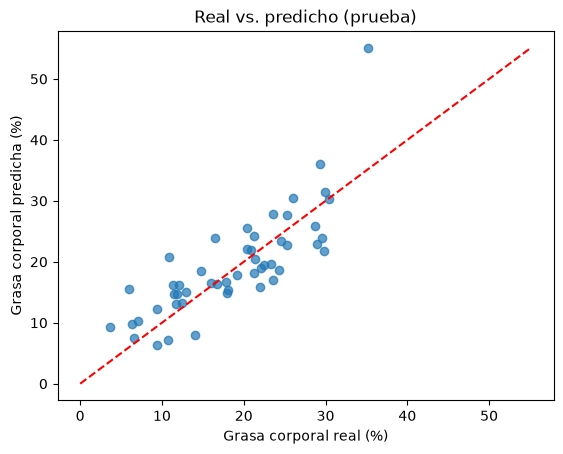

In [18]:
plt.scatter(y_test, y_pred, alpha=0.7)
limite = max(y_test.max(), y_pred.max())
plt.plot([0, limite], [0, limite], "r--")
plt.xlabel("Grasa corporal real (%)")
plt.ylabel("Grasa corporal predicha (%)")
plt.title("Real vs. predicho (prueba)")
plt.show()

El R2 de prueba es menor que el de validación cruzada. La causa principal es la persona de 165 kg: el modelo estimó cerca de 55 % cuando el valor real era 35 %. Con solo 50 filas de prueba, un único registro mueve mucho la métrica.

In [19]:
lasso = modelo.named_steps["modelo"]
coeficientes = pd.Series(lasso.coef_, index=VARIABLES).round(2)
print("alpha elegido: %.3f" % lasso.alpha_)
coeficientes[coeficientes != 0].sort_values()

alpha elegido: 0.212


wrist_cm     -1.41
height_cm    -0.66
biceps_cm     0.07
age           0.69
abdomen_cm    7.50
dtype: float64

Lasso conserva pocas variables y anula las demás. Con las variables estandarizadas, el abdomen domina por mucho.

### Predicción para una persona nueva

In [20]:
persona = pd.DataFrame([{"age": 35, "weight_kg": 80.0, "height_cm": 178.0, "neck_cm": 38.0, "chest_cm": 100.0,
                         "abdomen_cm": 90.0, "hip_cm": 99.0, "thigh_cm": 58.0, "knee_cm": 38.0, "ankle_cm": 23.0,
                         "biceps_cm": 32.0, "forearm_cm": 28.0, "wrist_cm": 17.5}])
print("Grasa corporal estimada: %.1f %%" % modelo.predict(persona[VARIABLES])[0])

Grasa corporal estimada: 18.0 %


---
# Conclusiones
---

## Resultados

Con medidas corporales simples es posible estimar la grasa corporal con un error medio de aproximadamente 4 puntos porcentuales, frente a 6.5 al predecir siempre el promedio. La circunferencia abdominal concentra casi toda la información útil: Lasso rinde igual con unas pocas variables que con las trece.

El hallazgo metodológico más importante es la fuga de información de `Density`. Un R2 de 0.99 parece excelente, pero no se puede usar en la práctica.

Limitaciones: el conjunto tiene solo 252 hombres adultos, así que el modelo no es válido para mujeres ni para menores. Las estimaciones son orientativas y no diagnósticas. Con medidas extremas el modelo extrapola mal, y por eso la API del proyecto avisa cuando una entrada sale del rango de entrenamiento.

### Referencias

> Johnson, R. W. (1996). Fitting percentage of body fat to simple body measurements. *Journal of Statistics Education*, 4(1).
> Penrose, K. W., Nelson, A. G., & Fisher, A. G. (1985). Generalized body composition prediction equation for men using simple measurement techniques. *Medicine & Science in Sports & Exercise*, 17(2), 189.
> Siri, W. E. (1956). The gross composition of the body. En *Advances in Biological and Medical Physics* (Vol. 4). Academic Press.
> Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society: Series B*, 58(1), 267-288.